## Universidad Panamericana Campus Aguascalientes
## Maestría en Inteligencia Artificial y Ciencia de Datos
### Aprendizaje Automático
**Práctica:** Árbol de Decisión

ID: 0286155

Alumno: Manuel Alejandro Serrano Macias

**Objetivo**: Entrenar y evaluar un modelo de regresión usando un árbol de decisión para predecir la **calidad del vino** (`quality`) a partir de sus propiedades. Posteriormente se compara con un modelo de **Random Forest**.

### 1. Importar librerías y leer el dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [2]:
# 1. Cargar dataset
df = pd.read_csv('wine.csv')
df.shape

(1599, 12)

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### 2. Dividir los datos en X (variables de entrada), y (variable de salida: quality)

In [4]:
# 2. Dividir los datos en X (variables de entrada) y Y (variable de salida: quality)
X = df.drop(columns=['quality'])
y = df['quality']

In [5]:
print('Variables de entrada (X):')
print(X.columns.tolist())

Variables de entrada (X):
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [6]:
print('Variable de salida (y):')
print(y.describe())

Variable de salida (y):
count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64


### 3. Dividir aleatoriamente: 70% entrenamiento y 30% prueba

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de prueba:        ', X_test.shape)

Tamaño del conjunto de entrenamiento: (1119, 11)
Tamaño del conjunto de prueba:         (480, 11)


### 4. Crear un árbol de decisión y mostrarlo

In [8]:
# Crea un árbol de decisión y mostrarlo
tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

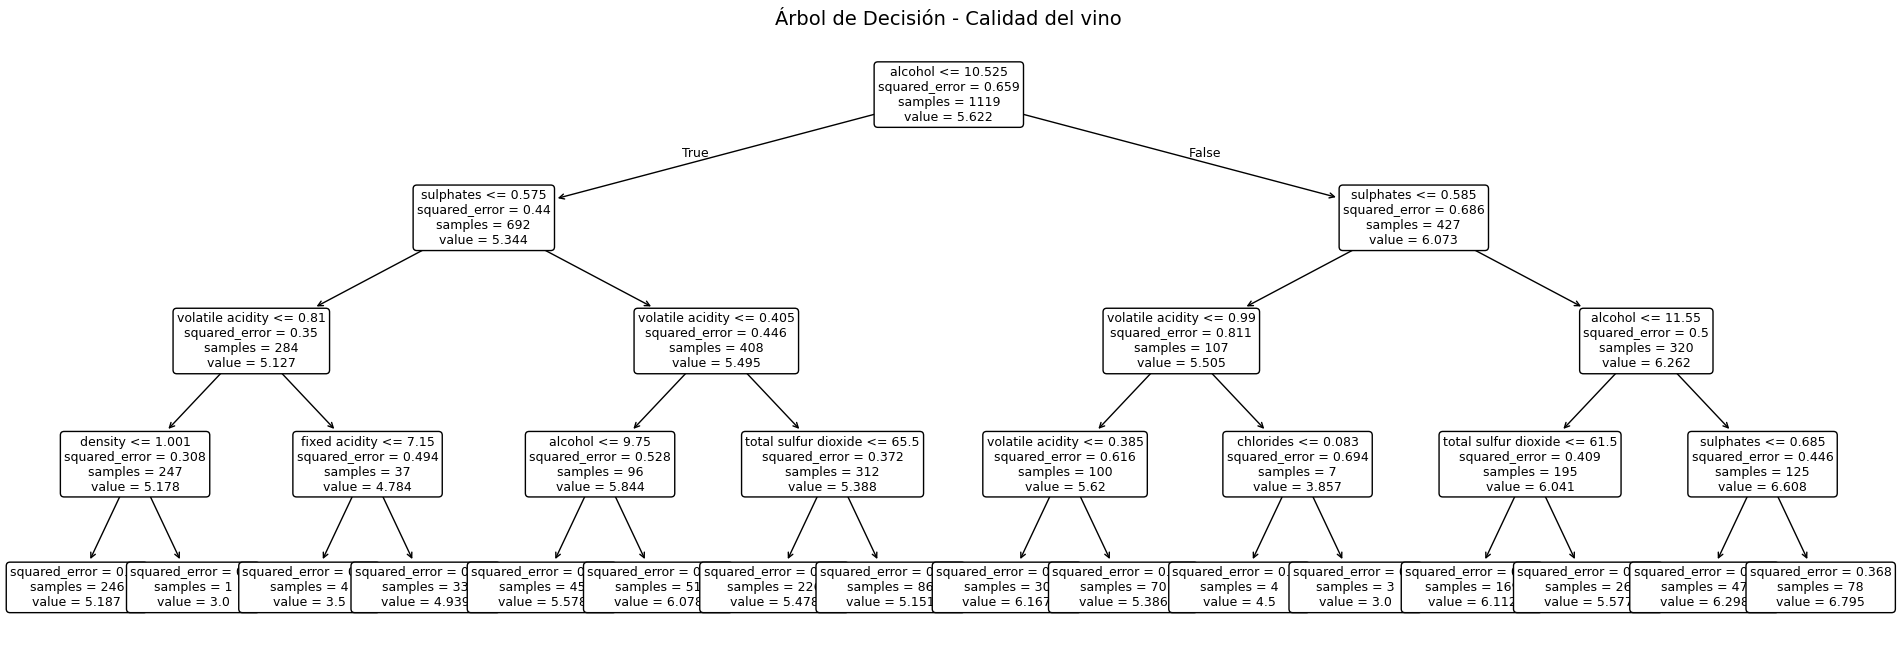

In [9]:
# Mostrar árbol (limitar profundidad para legibilidad)
plt.figure(figsize=(24, 8))
plot_tree(tree, feature_names=X.columns.tolist(), rounded=True, fontsize=9)
plt.title('Árbol de Decisión - Calidad del vino', fontsize=14)
plt.show()

### 5. Gráfica de dispersión: valores reales vs predichos

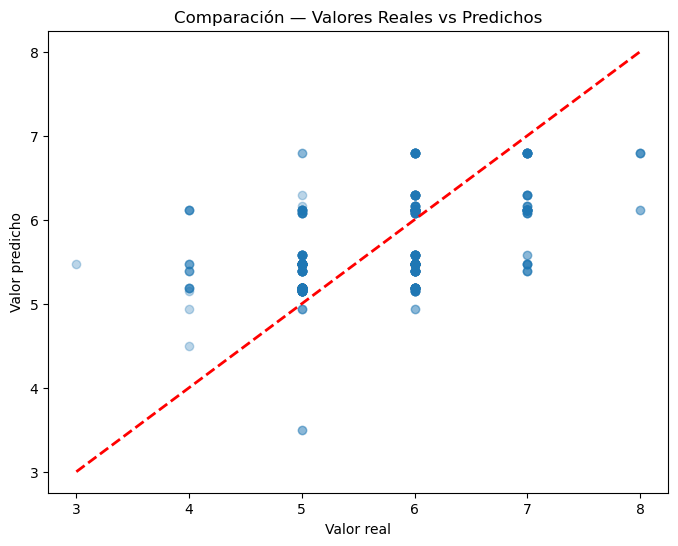

In [10]:
y_pred_tree = tree.predict(X_test)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_tree, alpha=0.3)
min_val = min(y_test.min(), y_pred_tree.min())
max_val = max(y_test.max(), y_pred_tree.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Comparación — Valores Reales vs Predichos')
plt.show()

¿Por qué hay puntos arriba y abajo de la línea roja?
* Puntos arriba de la línea: el modelo predijo un valor más alto que la calidad real, es decir, sobreestimó.
* Puntos abajo de la línea: el modelo predijo un valor más bajo que la calidad real, es decir, subestimó.

### 6. Desempeño del modelo: R² y MAE

Medimos qué tan bien le fue al modelo. R² nos dice qué porcentaje de la variación en la calidad logra explicar el modelo (entre más cercano a 1, mejor). MAE nos dice cuánto se equivoca el modelo en promedio.

In [11]:
r2_tree  = r2_score(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)

print('Árbol de Decisión')
print(f'R²  (coeficiente de determinación): {r2_tree:.4f}')
print(f'MAE (error absoluto medio):         {mae_tree:.4f}')
print()

Árbol de Decisión
R²  (coeficiente de determinación): 0.2554
MAE (error absoluto medio):         0.5475



### 7. Importancias de cada variable (Árbol de Decisión)

Vemos cuáles variables fueron las más útiles para que el árbol tomara decisiones. Entre más grande el valor, más importante fue esa variable para predecir la calidad.

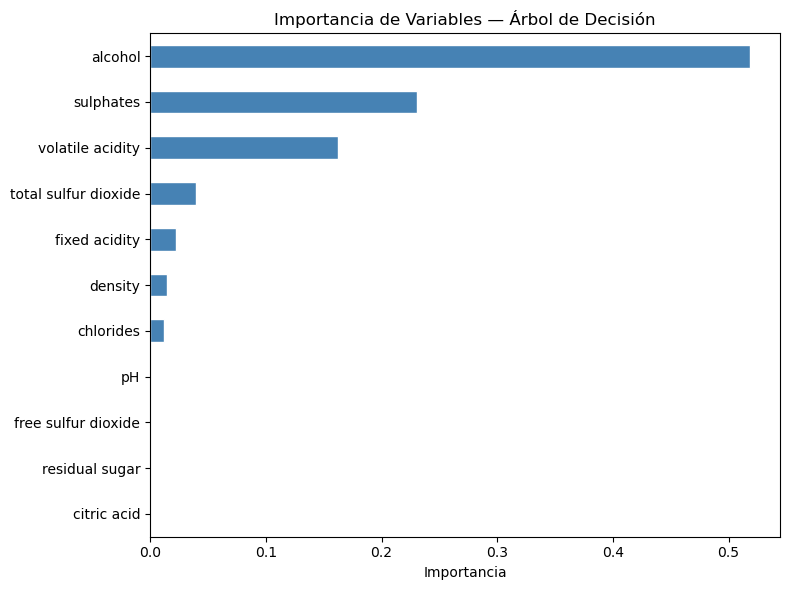


Importancias (orden descendente):
alcohol                 0.518443
sulphates               0.230888
volatile acidity        0.162208
total sulfur dioxide    0.039825
fixed acidity           0.022451
density                 0.014469
chlorides               0.011716
citric acid             0.000000
residual sugar          0.000000
free sulfur dioxide     0.000000
pH                      0.000000
dtype: float64


In [12]:
importancias_tree = pd.Series(tree.feature_importances_, index=X.columns)
importancias_tree_sorted = importancias_tree.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importancias_tree_sorted.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Importancia')
plt.title('Importancia de Variables — Árbol de Decisión')
plt.tight_layout()
plt.show()

print('\nImportancias (orden descendente):')
print(importancias_tree.sort_values(ascending=False))

## 8. Modelo Random Forest
Repetimos los pasos 4, 5, 6 y 7 usando **RandomForestRegressor**. En lugar de un solo árbol, este modelo entrena muchos árboles distintos y promedia sus predicciones. Así reduce los errores y generalmente da mejores resultados.

In [13]:
# Crear y entrenar el Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Random Forest entrenado con 100 árboles.


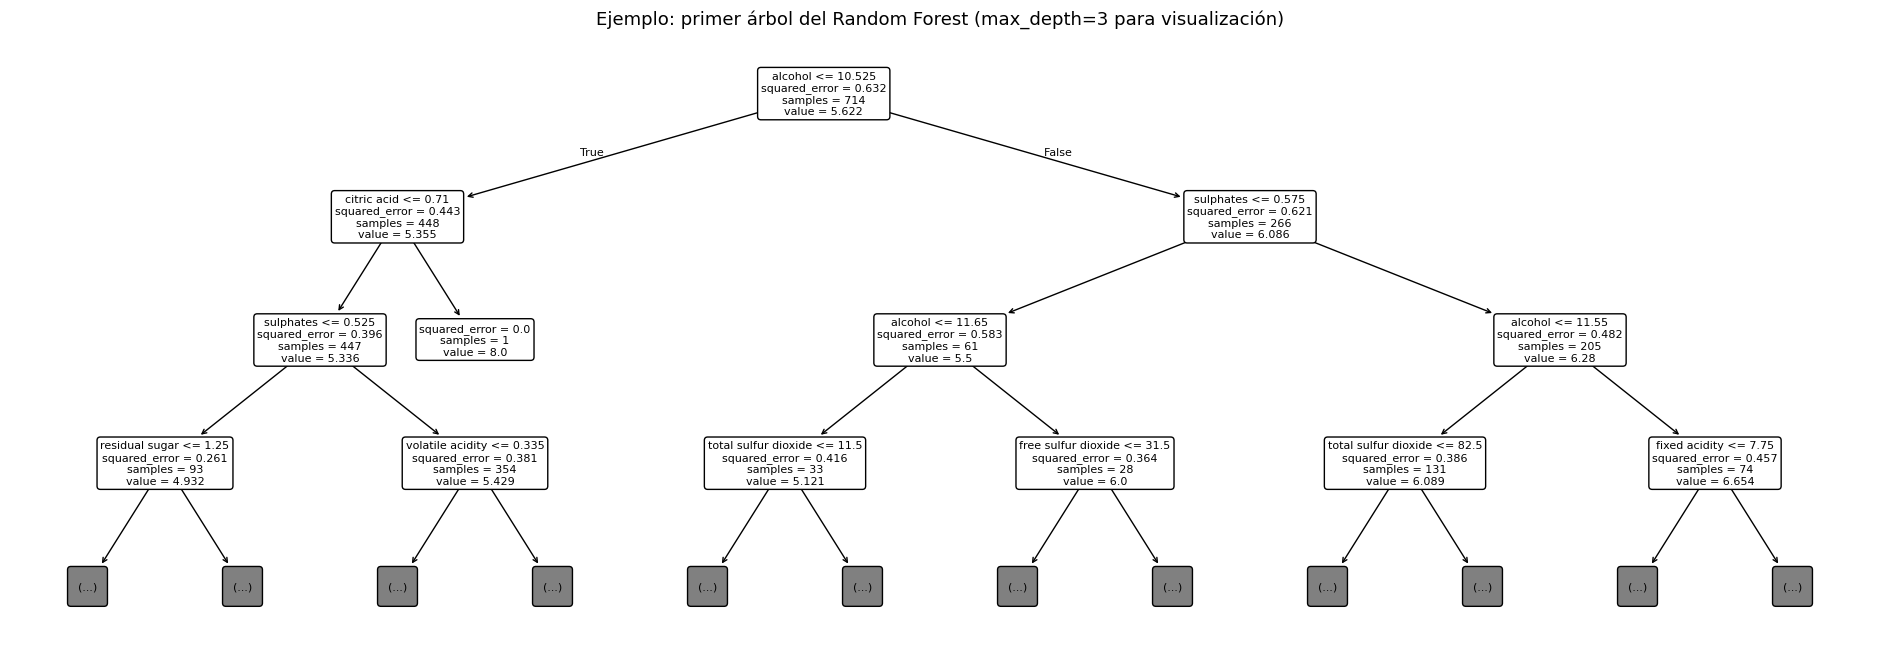

In [14]:
print('Random Forest entrenado con', rf.n_estimators, 'árboles.')

# Visualizamos el primer árbol del bosque como ejemplo
plt.figure(figsize=(24, 8))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns.tolist(),
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title('Ejemplo: primer árbol del Random Forest (max_depth=3 para visualización)', fontsize=13)
plt.show()

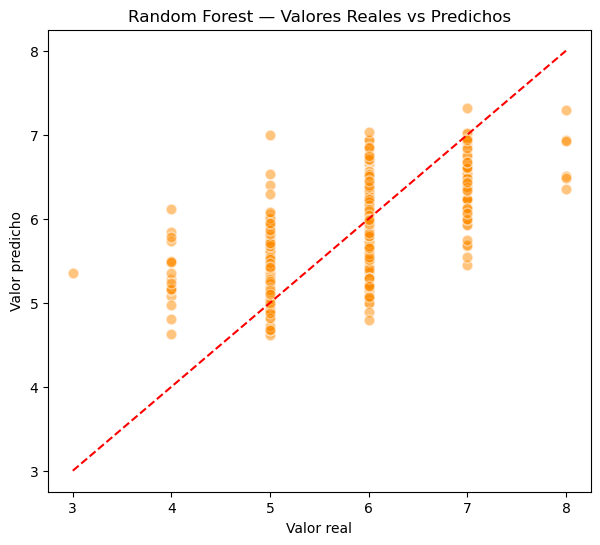

In [15]:
y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='darkorange', edgecolors='white', s=60)
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Random Forest — Valores Reales vs Predichos')
plt.show()

Comparamos los resultados de ambos modelos para ver cuál predice mejor la calidad del vino.

In [16]:
# Desempeño: R² y MAE
r2_rf  = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print('Random Forest')
print(f'R²  (coeficiente de determinación): {r2_rf:.4f}')
print(f'MAE (error absoluto medio):         {mae_rf:.4f}')
print()
print('Comparación de modelos')
print(f'{"Modelo":<25} {"R²":>8} {"MAE":>8}')
print('-' * 45)
print(f'{"Árbol de Decisión":<25} {r2_tree:>8.4f} {mae_tree:>8.4f}')
print(f'{"Random Forest":<25} {r2_rf:>8.4f} {mae_rf:>8.4f}')

Random Forest
R²  (coeficiente de determinación): 0.4507
MAE (error absoluto medio):         0.4441

Comparación de modelos
Modelo                          R²      MAE
---------------------------------------------
Árbol de Decisión           0.2554   0.5475
Random Forest               0.4507   0.4441


Vemos cuáles variables fueron las más útiles para el Random Forest. Podemos comparar con las importancias del árbol y ver si coinciden.

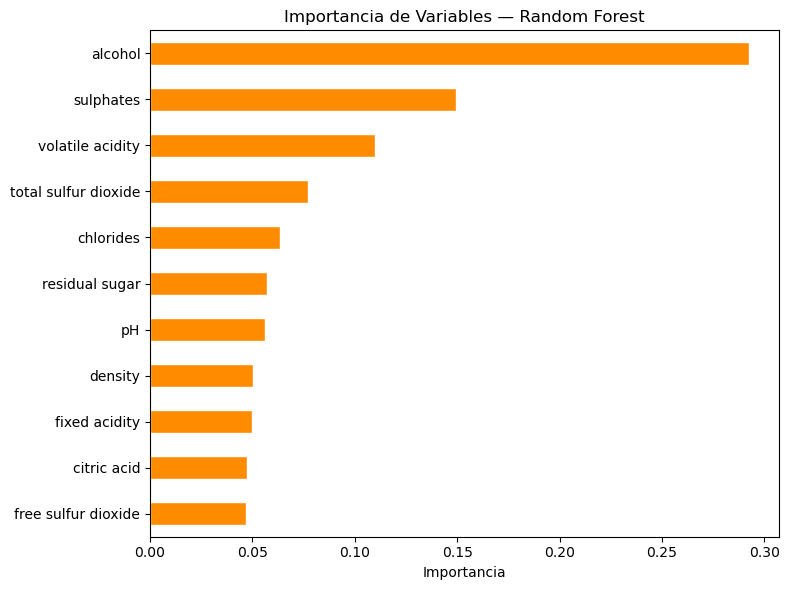


Importancias (orden descendente):
alcohol                 0.292471
sulphates               0.149310
volatile acidity        0.109989
total sulfur dioxide    0.077201
chlorides               0.063492
residual sugar          0.057148
pH                      0.056232
density                 0.050421
fixed acidity           0.049840
citric acid             0.047214
free sulfur dioxide     0.046681
dtype: float64


In [17]:
importancias_rf = pd.Series(rf.feature_importances_, index=X.columns)
importancias_rf_sorted = importancias_rf.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importancias_rf_sorted.plot(kind='barh', color='darkorange', edgecolor='white')
plt.xlabel('Importancia')
plt.title('Importancia de Variables — Random Forest')
plt.tight_layout()
plt.show()

print('\nImportancias (orden descendente):')
print(importancias_rf.sort_values(ascending=False))

## Conclusiones

* El árbol de decisión es fácil de interpretar y visualizar, pero puede sobreajustarse si no se limita su profundidad.
* El Random Forest entrena 100 árboles distintos y promedia sus resultados, por eso generalmente tiene mejor R² y menor MAE.
* En ambos modelos, el alcohol es la variable que más influye en la calidad del vino.
* Si el R² sube y el MAE baja con Random Forest, significa que el ensamble de árboles predice mejor que uno solo.